# W.00: The Uniform Distribution

\pagetab{W.00}

In [453]:
#! no-listings
# Import the numeric library for data handling
# and the matplotlib graphics library using
# the standard names
import matplotlib.pyplot as plot
import numpy as np
import scipy as sp
import pandas as panda
from matplotlib.ticker import (
    AutoMinorLocator,
    MultipleLocator,
)
from pandas import ExcelFile

# Import the statistics handling and plotting code
import statsmodels.graphics.gofplots as sm
import statsmodels.sandbox.distributions.extras as sm_extra

# Import the wrapper module to avoid long lines in the 'printed' version
import textwrap

In [454]:
#! no-listings
# Allow searching for file listings
import os.path

# Search for the 'fieldguide' style and 'fg_workshop' colour map. If these
# are not found, then it should default to the MatPlotLib defaults, which
# match the color sequence used in the FieldG Guides. Otherwise clear whatever
# style is in use, and use the styles as found
if os.path.isfile(
    "../../common/matplotlib/fieldguide.mplstyle"
):
    plot.style.use("default")
    plot.style.use(
        "../../common/matplotlib/fieldguide.mplstyle"
    )
if os.path.isfile(
    "../../common/matplotlib/workshops.mplstyle"
):
    plot.style.use(
        "../../common/matplotlib/workshops.mplstyle"
    )

# Define the core colour palette
signal_colours = {
    "yellow": "#f7ba0b",
    "orange": "#d4652f",
    "red": "#a02128",
    "violet": "#904684",
    "blue": "#154889",
    "green": "#317f43",
    "grey": "#9b9b9b",
    "brown": "#7b5141",
    "white": "#f4f4f4",
    "black": "#282828",
}

## Introduction

### Aim

This _Worksheet_ introduces you to both the _uniform distribution_, and the basics of using Jupyter to explore the distribution. The uniform distribution is a probability distribution where all outcomes in the sample space are equally likely to occur. This makes the uniform distribution the simplest of the distributions we will explore in the _Workshops_, and a good place to start. 

There are both a continuous and discrete form of the distribution, and we will look at the continuous form first. In its continuous form it also often called the *rectangular* distribution as this is the shape of the probability density function (PDF). 

Although the uniform distribution isn't that common in simulation by itself, it is the basis for a number of common analysis procedures. For instance when generating random numbers between bounds where all outcomes are equally likely (see _Explanation EC.02_ (_Monte Carlo_) for an typical example). 

### Learning Outcomes

* To understand the use of a measure of central tendency (mean) in defining a distribution
* To understand the use of a measure of variability (variance) in defining a distribution
* To understand both the PDF and CDF forms of the continuous and discrete uniform distribution
* To use NumPy and SciPy to calculate the basic properties of the continuous and discrete uniform distribution
* To use Matplotlib to plot distributions and numeric values

## The Continuous Uniform Distribution

### The Definition of the Continuous Uniform Distribution

The continuous uniform distribution is bounded by a minimum $a$ and maximum value $b$ which can either be closed $[a, b]$ or open $(a, b)$ in the sample space. In either case the values in [@tbl:W00_CUniformPDF] apply for the _probability density function_ (PDF) and the _cumulative density function_ (CDF).


| **Term** | **Expression**                                                                                                                   |
|----------|----------------------------------------------------------------------------------------------------------------------------------|
| Mean\vspace{1cm}     | $\mu = \dfrac{a+b}{2}$                                                                                                           |
| Variance\vspace{1cm} | $\sigma^2=\dfrac{(b-a)^2}{2}$                                                                                                   |
| Probability Density Function (PDF)\vspace{1cm}      | $f(x)={\begin{cases}{\dfrac {1}{b-a}}&{\text{for }}x \in [a, b],\\ 0&{\text{for }}x< a {\text{ or }}x > b\end{cases}}$           |
| Cumulative Density Function (CDF)\vspace{1.25cm}      | $F(x)={\begin{cases}0 & {\text{for }}x < a,\\ {\dfrac{x-a}{b-a}}&{\text{for }}x \in [a, b],\\ 1&{\text{for }}x > b\end{cases}}$  |

Table: Definitions of the Continuous Uniform Distribution {#tbl:W00_CUniformPDF}

### Calculating the Parameters of the Continuous Uniform Distribution in SciPy

In Jupyter, we use the [`uniform` class](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html) from the [SciPy](https://docs.scipy.org/doc/scipy/index.html) stats library to model the distribution. The function `uniform(loc, scale)` creates a uniform distribution with a lower bound of `loc` and an upper bound of `loc+scale`. Note the parameters to the `uniform` function are **not** the same as $a$ and $b$ as we will see shortly.

Start by importing the `uniform` class into your Python code using the following

In [455]:
from scipy.stats import uniform

Before we use SciPy, we will first run through the calculations for the uniform distribution where $a = 0.2$ and $b = 1.0$. Calculating the parameters using [@tbl:W00_CUniformPDF], this gives us the following

$$
\begin{aligned} 
    \mu &= \dfrac{0.2+1}{2}=0.6 \\
    \sigma^2 &= \dfrac{(1-0.2)^2}{12} = \dfrac{0.8^2}{12} = \dfrac{0.64}{12} = 0.05333 \\
    f(x) &= \begin{cases} \dfrac{1}{1 - 0.2}=1.25 & 0.2 \leq x \leq 1.0 \\ 0 & x < 0.2 \text{ or } x > 1.0 \end{cases} \\
    F(x) &= \begin{cases}0 & x < 0.2,\\ {\dfrac{x-0.2}{0.8}}&{0.2 \leq x \leq 1.0},\\ 1&x >1.0\end{cases}
\end{aligned}
$$

We will now check the results above, using the function in SciPy to calculate the different parameters. In SciPy the standard uniform distribution is defined over the interval $[0, 1]$. SciPy then uses the $\text{loc}$ and $\text{scale}$ parameters to modify the standard distribution, where '$\text{loc}$' is the 'location' of the new distribution and '$\text{scale}$' the scaled interval. This creates a new distribution over the interval $[\text{loc}, \text{loc} + \text{scale}]$: which is the one we want.

To make life easier, we will first set the standard parameters $a$ and $b$ to the values used above

In [456]:
# Set the standard parameters for the uniform distribution
a, b = 0.2, 1.0

Now we can calculate the `loc` and `scale` parameters as follows. The '$\text{loc}$' parameter is the 'location' of the distribution and effectively 'shifts' the left-hand side of the standard distribution. This value can be set directly as $\text{loc}=a$. The '$\text{scale}$' parameter, though, is the 'distance' between $a$ and $b$. This distance sets the position of the right-hand side of the distribution at $b$, relative to $\text{loc}$ ($a$) we set earlier. This distance is therefore determined by $\text{scale} = b - a$. So the final values we need are

In [457]:
# Calculate the location and scale parameters required by SciPy
# from the standard parameters
loc = a
scale = b - a

Calculating the mean and variance using SciPy requires using the [`stats`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html) function. All distributions within SciPy have this function: but not all distributions will have the same descriptors (called _moments_ in SciPy). We just need the mean, `m`, and variance, `v`, so the function call looks like 

In [458]:
# Calculating the mean and variance using the `stats` method
mean, var = uniform.stats(loc, scale, moments="mv")
print(f"a: {a: .2f}\nb: {b: .2f}\n")
print(f"Mean: {mean:.2f}\nVariance: {var:.4f}\n")

a:  0.20
b:  1.00

Mean: 0.60
Variance: 0.0533



This should give us the values we calculated earlier. Next we will calculate the PDF, $f(x)$, for the uniform distribution. We know from the earlier calculations that $f(x)$ should be $f(x)= 1.25$ for all values between $0.2$ and $1.0$ (that is between $a$ and $b$).

Again SciPy gives a common interface for all distributions for this task, using the [`pdf`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html#scipy.stats.uniform) method. The slight complication is we also need a data structure for $x = [a, b] = [0.2, 1.0]$, which we take from the [NumPy `linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) method. The `linspace` method returns a set of evenly spaced values between two limits (i.e. $a$ and $b$), and we will also tell `linspace` to only generate $10$ values for $x$ in this interval (using the third parameter)

In [459]:
# Generating 10 values for x in the interval [a , b]
x = np.linspace(
    a,
    b,
    10,
)

Now we can use the `pdf` method of SciPy to generate the PDF using the values of $x$ above

In [460]:
# Calculating the PDF for the uniform distribution.
U = uniform.pdf(x, loc, scale)

print("\nProbability Distribution: \n", U)


Probability Distribution: 
 [1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25]


Hopefully these values should be familiar from the earlier calculations.



### Plotting the PDF of the Continuous Uniform Distribution

#### Simple Plots

We will return to the cumulative probability distribution, $F(x)$, shortly. But first we will look at plotting the PDF we have just calculated. After all in most simulations we are not really interested in the mathematical properties of the distribution, as much as we are in the way they can model specific features of the problems under study. And those 'features' typically depend on the specific _shapes_ characteristic to different distributions.

We will plot only the PDF of the distribution we have been using so far. However in SciPy you can quickly get a 'frozen' copy of any `uniform` distribution with the parameters `loc` and `scale` by calling the distribution class with just those parameters 

In [461]:
# Create a specific instance of the uniform distribution with the
# parameters a and b
rand_uniform = uniform(loc, scale)

Calling `uniform` in this way sets up a _specific instance_ of the uniform distribution, using the scale parameters `loc` and `scale` (defined earlier)^[If you need the standard uniform distribution, then these parameters can be omitted.]. Whenever this instance (`rand_uniform`) is now used, the _shape_ of the distribution will not change.

One of the advantages of working in Jupyter is that you can also quickly plot the PDF of the distribution (or indeed anything else). To more easily see the shape of `rand_uniform` we will use the [Matplotlib](https://matplotlib.org/) library^[Maplotlib is a large library, but we will only introduce the basics here: the [cheatsheets](https://matplotlib.org/cheatsheets/) are a useful source of many of the available options.].

Before we start, we again need something to plot against for the $x$ axis. We will use the `linspace` function as before, but this time with a much denser plot between the limit values. In our case we will plot the PDF of `rand_uniform` between $0.0$ and $1.0$

In [462]:
# Generate the values for the x-axis between 0.0 and 1.0
uniform_x_values = np.linspace(0, 1.0, 100000)

# print("Distribution : \n", distribution)

With the values for $x$ generated, we can now generate $f(x)$ using the [`pdf`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html) method. We have already generated the uniform distribution itself (`rand_uniform`), so the PDF can be generated as '`rand_uniform.pdf(pdf_x_values)`'. Putting both the axis values in the plot then looks something like the following

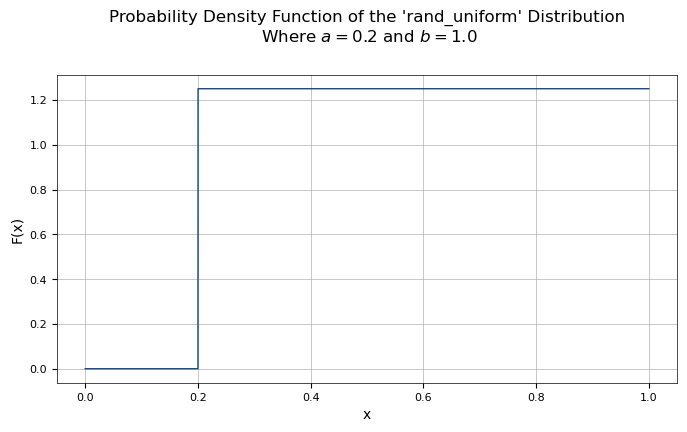

In [463]:
# The Plot of the Uniform PDF where $a = 0.2$ and $b = 1.0$
# in the Real Interval $[0.0, 1.0]$
# fig:W00_CUniformPDF1

x_axis = uniform_x_values
y_axis = rand_uniform.pdf(uniform_x_values)

# Plot the result
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")

# Label the axes
plot.xlabel("x")
plot.ylabel("F(x)")

# Label the plot
plot.title(
    "Probability Density Function of the 'rand_uniform' "
    "Distribution\n Where $a = $"
    + str(a)
    + " and $b = $"
    + str(b),
    pad=24.0,
)

# Display the graph
plot.plot(x_axis, y_axis)

Note the very sharp 'step' in [@fig:W00_CUniformPDF1] at the value for $a$ ($0.2$). Note also that the PDF goes _immediately_ at $a$ from $f(x) = 0.0$ to $f(x) = 1.25$. This step (or impulse) at $a$ is characteristic of the uniform distribution.

What happens, though, at (and past) the limit $b$? Extending our view past $1.0$ in [@fig:W00_CUniformPDF1], we can extend the $x$ values to cover the interval $[0.0, 2.0]$

In [464]:
# Generate the values for the x-axis between 0.0 and 3.0
uniform_x_values = np.linspace(0, 2.0, 100000)

Replotting [@fig:W00_CUniformPDF1] over this interval gives the plot shown in [@fig:W00_CUniformPDF2]. In [@fig:W00_CUniformPDF2] we can see the sharp fall at $x = b = 1.0$, so that $f(x) = 0.0$.

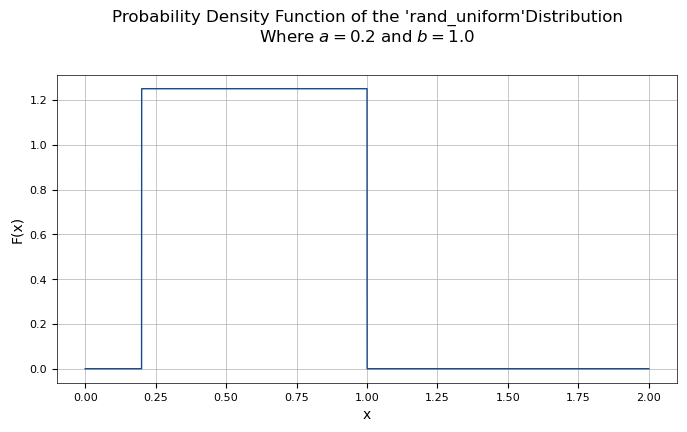

In [465]:
# The Plot of the Uniform PDF where $a = 0.2$ and $b = 1.0$
# in the Real Interval $[0.0, 2.0]$ Showing the Characteristic
# Rectangular Shape
# fig:W00_CUniformPDF2

x_axis = uniform_x_values
y_axis = rand_uniform.pdf(uniform_x_values)

# Plot the result
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")

# Label the axes
plot.xlabel("x")
plot.ylabel("F(x)")

# Label the plot
plot.title(
    "Probability Density Function of the 'rand_uniform'"
    "Distribution\nWhere $a = $"
    + str(a)
    + " and $b = $"
    + str(b),
    pad=24.0,
)

# Display the graph
plot.plot(x_axis, y_axis)

The resulting rectangular shape in [@fig:W00_CUniformPDF2] between $a$ and $b$ is characteristic of the uniform distribution. Indeed the uniform distribution is sometimes known as the _rectangular distribution_ from the shape of the PDF. 

#### Formatting the Axis Spacing

Just before we the leave the topic of plotting the PDF, you will note that in [@fig:W00_CUniformPDF2] the choice of spacing on the $x$ axis is not quite optimal. So far we have left the choice of spacing to `matplotlib`, and most of the time it will calculate a 'reasonable' interval. However if we want to emphasise the step at $a$, it would be useful to reduce the interval on the $x$ axis to $0.2$, rather than $0.25$.

A simple way to do this is to use the [NumPy `arange`](https://numpy.org/doc/stable/reference/generated/numpy.arange.html) method. Using `arange` is very similar to the `linspace` method we have used previously. However for `linspace` we tell NumPy _how many_ values we want in the interval, and NumPy works out the spacing for us. By contrast with `arange` we tell NumPy what _spacing_ (step value) we want in the interval, and NumPy works out how many values to return. 

**Note:** The `arange` method works over the interval $[start, stop)$, rather than the interval $[start, stop]$ used for `linspace`. Since we know the step, the easiest way to compensate for this (aside from modifying the axis interval) is to stop the interval _one past_ the value we need.

In [466]:
# Create an array in the interval [0.0, 2.0], in steps of 0.2
x_axis_ticks = np.arange(0.0, 2.2, 0.2)

Now we can use the `x_axis_ticks` in the plot, passing it the the [`xticks` method](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xticks.html). A similar process also works for the $y$ axis: and now that we have a variable we can also 'reuse' the same range for other plots.

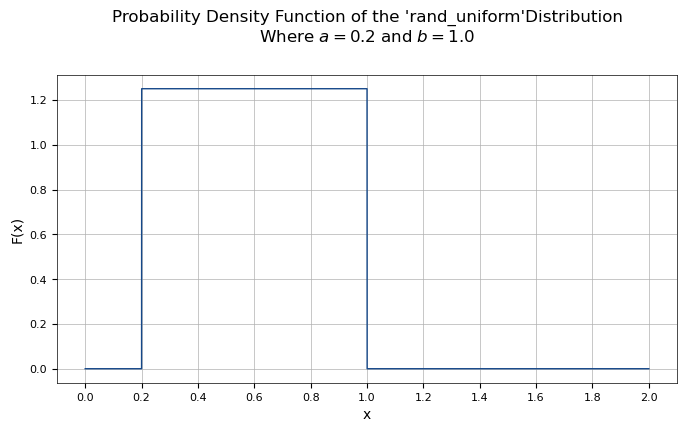

In [467]:
# The Plot of the Uniform PDF where $a = 0.2$ and $b = 1.0$
# in the Real Interval $[0.0, 2.0]$ Using Revised Tick Markers
# fig:W00_CUniformPDF3

x_axis = uniform_x_values
y_axis = rand_uniform.pdf(uniform_x_values)

# Plot the result
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")

# Format the axes
plot.xticks(x_axis_ticks)

# Label the axes
plot.xlabel("x")
plot.ylabel("F(x)")

# Label the plot
plot.title(
    "Probability Density Function of the 'rand_uniform'"
    "Distribution\nWhere $a = $"
    + str(a)
    + " and $b = $"
    + str(b),
    pad=24.0,
)

# Display the graph
plot.plot(x_axis, y_axis)

You should now have a good idea of how to shape other uniform distributions using the $a$ and $b$ parameters, and you can try modifying the code above to experiment. If you modify the `a` and `b` variables for the new values of $a$ and $b$ that you want, remember to rerun the calculations for `loc` and `scale`! Modifying `loc` or `scale` directly should adjust the following PDF calculations: but they might not then match the earlier values of `a` and `b`. Sometimes it is easier in Juypter to restart the worksheet: or at least run all the cells again when modifying values for a series of calculations. 

### Plotting the CDF of the Continuous Uniform Distribution

Calculating, and plotting, the CDF ($F(x)$) of the uniform distribution is very similar to the process we have just used for the PDF ($f(x)$). Instead of using the `pdf` method of the `uniform` class, however, we use the [`cdf` method](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html). You will still need to give a range for this function to work over, and here we will reuse the $x = [0.0, 2.0]$ interval currently in `uniform_x_values`. We wil also reuse the interval for the $x$ asis, `x_axis_ticks`, calculated earlier. This makes the CDF plot in [@fig:W00_UniformCDF1] easier to compare to the PDF plot in [@fig:W00_CUniformPDF3]






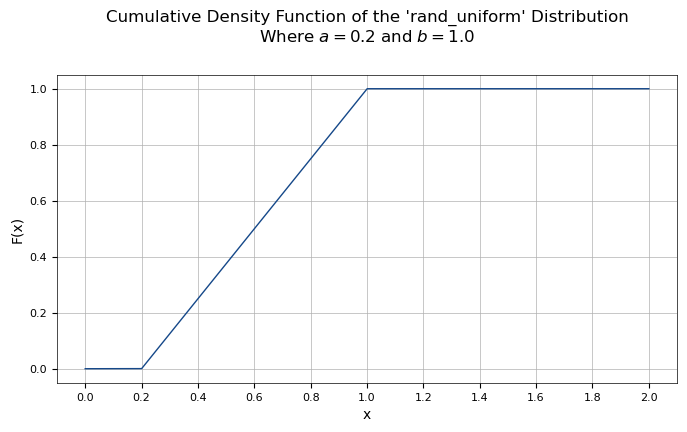

In [468]:
# The Plot of the Uniform CDF where $a = 0.2$ and $b = 1.0$
# in the Real Interval $[0.0, 3.0]$
# fig:W00_UniformCDF1

x_axis = uniform_x_values
y_axis = rand_uniform.cdf(uniform_x_values)

# Plot the result
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")

# Format the axes
plot.xticks(x_axis_ticks)

# Label the axes
plot.xlabel("x")
plot.ylabel("F(x)")

# Label the plot
plot.title(
    "Cumulative Density Function of the 'rand_uniform' "
    "Distribution\nWhere $a = $"
    + str(a)
    + " and $b = $"
    + str(b),
    pad=24.0,
)

plot.plot(x_axis, y_axis)

Looking at [@fig:W00_UniformCDF1], the resulting shape of the CDF should also be apparent from the basic definitions in [@tbl:W00_CUniformPDF]. From [@tbl:W00_CUniformPDF], in the interval $[a, b]$

$$F(X) = \frac{x - a}{b - a}$$

Since $x$ is a linear (fist-order) polynomial and $(b-a)$ is constant, we would expect $F(X)$ for the _uniform_ distribution to have a constant 'rate of change' between the limits $a$ and $b$. In other words as a graph, a line with a constant gradient (slope) between $a$ and $b$.

However, the function $F(x)$ also gives the _cumulative_ probability of the distribution: and the probability $p$ must lie in the interval $p = [0.0, 1.0]$. So the cumulative change in _probability_ should only occur in the interval $[a, b]$ from $p = 0.0$ at $a$ to $p = 1.0$ at $b$. With a constant gradient, the final graph should look something like [@fig:W00_UniformCDF1]. You can verify this by changing the values of $a$ and $b$ as before, and re-calculating (then re-plotting) the relevant variables. 

### Using the PDF of the Continuous Uniform Distribution

#### Uses of Random Numbers

Before the leave the definitions of the continuous uniform distribution in  [@tbl:W00_CUniformPDF] behind, we will also stop to look at _why_ we are using these distributions at all. This applies not only to the continuous uniform distribution, but also the discrete uniform distribution we will look at shortly (and the other distribution in other _Workshops_).

In most cases we are using the distributions to generate _random_ numbers: especially for simulations. Different processes have different characteristic shapes when plotted, in the same what that different data sets also show patterns. To study the underlying process, or data, we therefore need models that also output numbers that fit the pattern we want. More specifically we need _random numbers_ to fit this pattern, as a single data point isn't that useful. Instead we want a 'simulated' set of data with the same basic properties as the data we started with.

Randomness is a surprisingly deep concept in mathematics, but intuitively we think of 'random' as something with _an equal probability_. For instance the flip of a coin, or the roll of a dice^[Although these are _discrete_ and not _continuous_ probabilities. We will discuss the discrete uniform distribution that would actually be used to model these phenomena shortly.]. We don't want some number to be more prevalent (or rarer) in the data, but instead expect every number to turn up with the same frequency.

And this 'intuitive' sense of randomness is exactly what the uniform distribution gives us. A set of numbers with a fixed probability of being chosen between two limits ($a$ and $b$), as for instance in [@fig:W00_UniformCDF1].

#### Obtaining Random Variates 

In statistics, we use the distributions to shape the overall probability space. Then these 'random numbers' are strictly called _random variates_, since we are drawing random _realisations_ of the underlying distribution. In other words, the 'random numbers' should have the same 'randomness' as they would have in the parent distribution they are being drawn from.

For example, in our example distribution we have already defined the shape of the uniform distribution through the `loc` and `scale` variables

In [469]:
# Redisplaying the location and scale of the running examples
print(f"Location: {loc}\nScale: {scale}")

Location: 0.2
Scale: 0.8


Using the [`rvs` method](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html) (random variates) of the `uniform` class we can generate five examples from this distribution by^[Note the slightly complex     `formatter` statement used in lines 3--4. Python format strings do not currently (Python 3.12) allow native formatting for the array we will obtain from the `uniform.rvs()` method. So instead we will use the NumPy [`array2string` method](https://numpy.org/doc/stable/reference/generated/numpy.array2string.html) to set a new format string for elements of the `float` type. That format string, in turn, uses the Python [`lambda` function](https://www.w3schools.com/python/python_lambda.asp) to return a formatted string (in this case formatted to 3 decimal places) for each member of the array which can be coerced to a `float`. In this case that should be all the values of `R`, and so we should then end up with the formatted array we wanted.] 

In [470]:
# Generating random variates (numbers) between two limits
R = uniform.rvs(loc, scale, size=5)
print(f"Random Variates: {np.array2string(R, 
    formatter={'float': lambda x: f'{x:.3f}'})}")

Random Variates: [0.341 0.388 0.215 0.493 0.725]


We have also previously defined the `rand_uniform` distribution with the properties we want, so we could also do

In [471]:
# Generating a second set of random variates from rand_uniform
print(
    f"Random Variates: {np.array2string(rand_uniform.rvs(5), 
    formatter={'float': lambda x: f'{x:.3f}'})}"
)

Random Variates: [0.416 0.318 0.996 0.561 0.273]


Note that if you re-run either cell in Jupyter you will get _different_ values. They should all conform to the underlying uniform distribution you specified, but they (should) be _randomly_ drawn. 

Sometimes we do want these numbers to change at different points of the code. But often we want to generate a specific set of random numbers _once_ and then use this set in different ways. For instance if you are modelling the input to a process, you might want to use the _same_ input to that process as other model values change. If the input is also random, then it makes it harder to untangle the dependencies between those values. 

If you do need to 're-use' a specific set of random number you will need to put them into a variable as we did above. So for instance the following should show the _same_ set of numbers as in `R` above

In [472]:
# Generating random variates from rand_uniform
print(f"Random Variates: \
    {np.array2string(R, 
    formatter={'float': lambda x: f'{x:.3f}'})}")

Random Variates:     [0.341 0.388 0.215 0.493 0.725]


But the following should be different

In [473]:
print(f"Random Variates: \
    {np.array2string(uniform.rvs(loc, scale, size=5),
    formatter={'float': lambda x: f'{x:.3f}'})}")

Random Variates:     [0.632 0.726 0.841 0.391 0.633]


### Plotting Distributions by Hand

#### Rolling Your Own

So far we have been using the SciPy library to handle the generation of the PDF and CDF for us. However you can also generate the required values 'by hand' using the definitions in [@tbl:W00_CUniformPDF]. The advantages of this approach are that

1. You don't need to rely on a a large and complex library. We will use NumPy in the example below, but in theory you could eliminate this dependency as well and just use plain Python methods.
2. You may be able to optimise the calculations in some cases. For some platforms, especially embedded systems, you may have restrictions on features such as floating point calculations. Equally on large platforms you can often exploit operations such as native vector calculations to help speed up large calculations
3. It can help to understand exactly what is going on: especially for complex formulae, or cases where the results are not quite what you expect 

The disadvantages of 'rolling you own' are that

1. You own all the bugs. The NumPy and SciPy libraries are _very_ well tested by a large audience. This doesn't make them bug free, but does mean bugs are in theory more likely to be found. Unless you are using a particularly obscure platform or language, it is likely that there will be a good numerical computation library available. Again this is much more likely to produce robust answers
2. Since both NumPy and SciPy are used extensively, there has been a _lot_ of effort put into optimisation. This is also the case with most numerical and statistical libraries on most platforms and in most languages. So again unless you have a particularly obscure case, the default set-up is likely to be (nearly) optimal.

 

#### Plotting the PDF

With that said, we will plot the uniform distribution 'by hand' in the section to better understand what is going on. In this case we will also compare our own results to the results obtained using SciPy to see if there are any major differences.

Starting with SciPy, we will use the same example distribution as before (where $a = 0.2$ and $b = 1.0$). This example distribution should be in `rand_uniform`, and we will assign this distribution to the variable `y1`, as we will shortly be plotting the results on two $y$ axes and a common $x$ axis. The $x$ axis itself we have also used before, and that interval $x = [0.0, 2.0]$ should be in `uniform_x_values`. So the code for the first $y$ axis is 

In [474]:
# Get the PDF of the uniform distribution used as a running example
y1 = rand_uniform.pdf(uniform_x_values)

Now we will calculate the values for the second $y$ axis. This means using the following formula from [@tbl:W00_CUniformPDF] in the interval $[a, b]$

$$y_2 = \frac{1}{b-a}$$

Outside the interval $[a, b]$, $y_2$ should be $0$. This allows us to use a small optimisation through the NumPy [`zeros_like` method](https://numpy.org/doc/stable/reference/generated/numpy.zeros_like.html). Passing the $x$ axis values (`uniform_x_values`) to the `zeros_like` method will return an all zero array with the same 'shape' as the input. In other words, here a one dimensional array with exactly the same number of zeroes as we have values for $x$. 

Using this methods means

1. We tell Python (NumPy) _exactly_ how big we want the result array to be. This means we can potentially allocate the memory for the array in one call, or use whatever platform optimisations are required to make this allocation 'efficient'.
2. We don't have the (re-)calculate the $0$ values, meaning we can just focus on the values that will change: that is, those $y$ values in the interval $[a, b]$.

Putting the calls together, we get something like

In [475]:
# Calculate a new PDF from the formula over the range of
# x-axis values specified in `uniform_x_values`
j = 0
y2 = np.zeros_like(uniform_x_values)

for i in uniform_x_values:

    if i >= a and i <= (b):
        y2[j] = 1 / (b - a)

    j = j + 1

Plotting the two distributions is much the same as before. The only differences are in lines `28`--`30`, where two arguments are used to the `plot` method. This allows us to show on the same plot in [@fig:W00_HandPlot1] the PDF from the library in a solid blue line, and the calculated PDF as a dashed orange line.

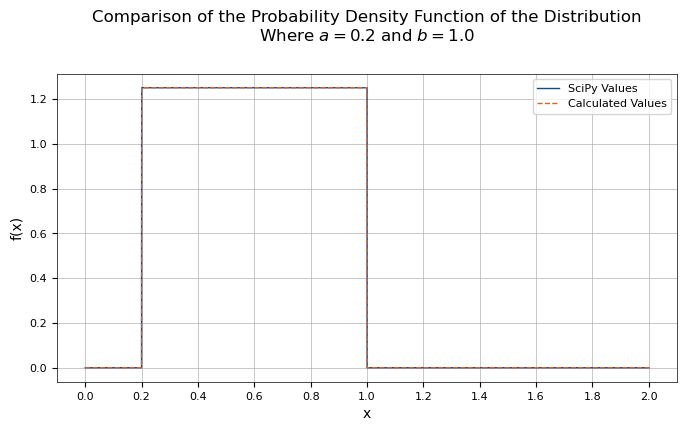

In [476]:
# Comparison of the PDF Output from the SciPy library and
# Direct Calculation for the Uniform Distribution
# fig:W00_HandPlot1

# Plot the results
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")

# Format the axes
plot.xticks(x_axis_ticks)

# Label the axes
plot.xlabel("x")
plot.ylabel("f(x)")

# Label the plot
plot.title(
    "Comparison of the Probability Density Function of the "
    "Distribution\nWhere $a = $"
    + str(a)
    + " and $b = $"
    + str(b),
    pad=24.0,
)

# Plot the two y-axes on the same plot
plot.plot(
    uniform_x_values,
    y1,
    linestyle="solid",
    label="SciPy Values",
)
plot.plot(
    uniform_x_values,
    y2,
    linestyle="dashed",
    label="Calculated Values",
)

# Add a legend
plot.legend(loc="best")

#### Plotting the CDF

The CDF is much the same process, using again the definitions from [@tbl:W00_CUniformPDF]. Here the definition of the CDF is a little more complicated, so there are a few more steps

Starting with the basic definition of the CDF for the uniform distribution

$$F(x)={\begin{cases}0 & {\text{for }}x < a,\\ {\dfrac{x-a}{b-a}}&{\text{for }}x \in [a, b],\\ 1&{\text{for }}x > b\end{cases}}$$

Obtaining the reference CDF from the `rand_uniform` distribution is much the same as before. This gives the first $y$ axis

In [477]:
# Get the CDF of the uniform distribution used as a running example
y1 = rand_uniform.cdf(uniform_x_values)

The region where $F(x) = 0$ ($x < a$) is already taken care of if we start with an all zero array (using the `zeros_like` method). Similarly we can detect when $x > b$, setting $F(X)$ to $1$. In the region $a < x < b$

$$y_2 = \frac{x-a}{b-a}$$

This is relatively straightforward to code, and so the resulting fragment for the second $y$ axis looks something like

In [478]:
# use formula to create CDF
j = 0
y2 = np.zeros_like(uniform_x_values)
for i in uniform_x_values:

    if i >= a and i <= (b):
        y2[j] = (i - a) / (b - a)
    elif i > (b):
        y2[j] = 1

    j = j + 1

As with the PDF we compare the library version (blue solid line) with the calculated version (orange dashed line) in [@fig:W00_HandPlot2]. These two lines should coincide, showing the agreement between the two methods.

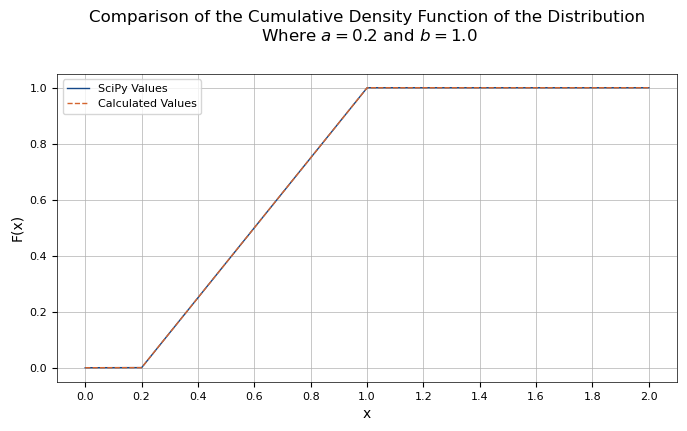

In [479]:
# Comparison of the CDF Output from the SciPy library and
# Direct Calculation for the Uniform Distribution
# fig:W00_HandPlot2

# Plot the results
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")

# Format the axes
plot.xticks(x_axis_ticks)

# Label the axes
plot.xlabel("x")
plot.ylabel("F(x)")

# Label the plot
plot.title(
    "Comparison of the Cumulative Density Function of the "
    "Distribution\n Where $a = $"
    + str(a)
    + " and $b = $"
    + str(b),
    pad=24.0,
)

# Plot the two y-axes on the same plot
plot.plot(
    uniform_x_values,
    y1,
    linestyle="solid",
    label="SciPy Values",
)
plot.plot(
    uniform_x_values,
    y2,
    linestyle="dashed",
    label="Calculated Values",
)

# Add a legend
plot.legend(loc="best")

## The Discrete Uniform Distribution

### The Definition of the Discrete Uniform Distribution

Like the continuous uniform distribution, the discrete uniform distribution is also bounded by a minimum $a$ and maximum value $b$. The discrete interval $[[a \ldots b]]$ has $n=b-a+1$ discrete values, and is also represented as the set $\left\{a, a+1, a+2, \ldots, b-1, b\right\}$. 

The use of discrete values also means we change the probability _density_ function of the continuous uniform distribution to a probability _mass_ function (PMF). The CDF remains much the same, although is now called the cumulative _distribution_ function (_not_ the cumulative _density_ function used in the continuous version). For both the PMF and CDF note the differences to account for the non-continuous interval between $a$ and $b$ in [@tbl:W00_DUniformPDF].


| **Term** | **Expression**                                                                                                                   |
|----------|----------------------------------------------------------------------------------------------------------------------------------|
| Number of Discrete Values     | $n = b - a +1$                                                                                                           |
| Mean     | $\mu = \dfrac{a+b}{2}$                                                                                                           |
| Variance | $\sigma^2=\dfrac{(b-a+1)^2-1}{12}$                                                                                                   |
| Probability Mass Function (PMF)      | $f[x]={\begin{cases}{\dfrac {1}{n}}&{\text{for }}x \in [[a \ldots b]],\\ 0&{\text{for }}x< a {\text{ or }}x > b\end{cases}}$           |
| Cumulative Distribution Function (CDF)      | $F[x]={\begin{cases}0 & {\text{for }}x < a,\\ {\dfrac{x-a+1}{n}}&{\text{for }}x \in [[a \ldots b]],\\ 1&{\text{for }}x > b\end{cases}}$  |

Table: Definitions of the Discrete Uniform Distribution {#tbl:W00_DUniformPDF}

### Calculating the Parameters of the Continuous Uniform Distribution in SciPy

**Note:** In this _Workbook_ we have already loaded the SciPy library, so we will not do so again. You will, though, need to do so for your own notebooks if you have not already done so.

In the SciPy stats library the [`randint` class](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html) creates a uniform discrete random variable. Just as before we do not use the $a$ and $b$ parameters of the discrete uniform distribution directly, but instead need to use the shape parameters `low` and `high`. Using the method [`randint(low, high)`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html#scipy.stats.randint) creates a discrete uniform distribution with a lower bound of `low` and an upper bound of `high - 1` for $x \in 1\{\text{low}, \text{low}+1, ..., \text{high}-1\}$. 

Our running example this time will be bounded by $a = 6$ and $b =10$. Using the expressions in [@tbl:W00_DUniformPDF] above, this should create a discrete uniform distribution with the following values

$$
\begin{aligned} 
    n &= 10 - 6 +1 = 5 \\
    \mu &= \dfrac{6+10}{2}=8 \\
    \sigma^2 &= \dfrac{(10-6+1)^2-1}{12} = \dfrac{5^2-1}{12} = \dfrac{24}{12} = 2 \\
    f[x] &= \begin{cases} \dfrac{1}{5}=0.2 & x \in \{6,7,8,9,10\} \\ 0 & x < 6 \text{ or } x > 10 \end{cases} \\
    F[x] &= \begin{cases}0 & {\text{for }}x \leq 5,\\ \frac{6-6+1}{5} = 0.2 & {x=6},\\ \frac{7-6+1}{5} = 0.4 & {x=7},\\ \frac{8-6+1}{5} = 0.6 & {x=8},\\ \frac{9-6+1}{5} = 0.8 & {x=9},\\ 1&{\text{for }}x \geq 10\end{cases}
\end{aligned}
$$

To calculate these values in SciPy we first set $a$ and $b$ as before

In [480]:
# Setting the parameters for the discrete uniform distribution
a, b = 6, 10

We now need to set the bounds to the discrete uniform distribution. Note that the value of `high` **must** to be `b + 1` since the `randint` class will use the internal upper bound `high - 1` for the distribution shape

In [481]:
low = a
high = b + 1

Now we can calculate the mean and variance using the `stats` method of `randint` as before

In [482]:
# Calculating the mean and variance using the `stats` method
mean, var = sp.stats.randint.stats(low, high, moments="mv")
print(f"a: {a: d}\nb: {b: d}\n")
print(f"Mean: {mean: .0f}\nVariance: {var: .0f}\n")

a:  6
b:  10

Mean:  8
Variance:  2



Next we need the range of discrete values between $a$ and $b$. There is a slight challenge here as NumPy works on `float` (floating point) values by default, not integers. So we will use the [`arange` function](https://numpy.org/doc/stable/reference/generated/numpy.arange.html#numpy.arange) and make sure the `step` size between values is `1`. The second challenge is that `arange` calculates the discrete interval $[[a \ldots b))$, so we also need to use $b + 1$ as the upper limit 

In [483]:
# Use `arange` to create an array of 'integer' values
# equally spaced between a and b
x = np.arange(
    a,
    b + 1,
    step=1,
)

print(f"x: {x}")

x: [ 6  7  8  9 10]


With the range for $x$ calculated, we can now calculate the probability mass function (PMF) using the [`pmf` method](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html#scipy.stats.randint) of `randint`

In [484]:
# Calculate the PMF for the discrete interval $a$ and $b$
R = sp.stats.randint.pmf(x, low, high)
print(
    f"Discrete Variable: \
    {np.array2string(x, precision=2, floatmode='fixed')}\n"
    f"Probability Distribution: \
    {np.array2string(R, formatter={'float': lambda x: f'{x:.1f}'})}"
)

Discrete Variable:     [ 6  7  8  9 10]
Probability Distribution:     [0.2 0.2 0.2 0.2 0.2]


The calculation of the cumulative distribution function (CDF) is essentially identical, using the [`cmf` method](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html#scipy.stats.randint) of `randint`

In [485]:
# Calculate the CDF for the discrete interval $a$ and $b$
R = sp.stats.randint.cdf(x, low, high)
print(
    f"Discrete Variable: \
    {np.array2string(x, precision=2, floatmode='fixed')}\n"
    f"Probability Distribution: \
    {np.array2string(R, formatter={'float': lambda x: f'{x:.1f}'})}"
)

Discrete Variable:     [ 6  7  8  9 10]
Probability Distribution:     [0.2 0.4 0.6 0.8 1.0]


Again these values should be checked against the earlier calculations to verify. You can also try calculating other values of $a$ and $b$, and make sure both your calculations and the library code agree with each other.

### Plotting the Discrete Uniform Distribution

#### Plotting the PMF and CDF

Plotting the discrete uniform distribution is much the same process as we used for the continuous version. The only slight difference is that plots _should not_ use lines to connect the elements of the PMF, as the 'intermediate values' strictly don't exist (and haven't been calculated.). 

For both the PMF and CDF, we first need to obtain the range of $x$ values for $f(x)$ and $F(x)$. In both cases the discrete interval $[[a \ldots b]]$, so we will use the discrete range of $x$ values from $0$ to $15$. As before we will use the [NumPy `arange`](https://numpy.org/doc/stable/reference/generated/numpy.arange.html) method, setting the `step` to `1` to force the discrete interval

**Note:** Remember the `arange` method works over the interval $[[start ... stop))$, rather than the interval $[[start ... stop]]$. Since we know the step, the easiest way to compensate for this (aside from modifying the axis interval) is to stop the interval _one past_ the value we need.

In [486]:
uniform_x_values = np.arange(start=0, stop=16, step=1)
print("X Axis Interval:\n", uniform_x_values)

X Axis Interval:
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


We can now plot the PMF over the `uniform_x_values` interval using the [`pmf` method](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html#scipy.stats.randint) of `randint` as before. To make this code slightly more compact, rather than creating a separate variable, we will call the `pmf` method directly for the calculation of the $y$ axis. You can see this in `Line 30` of the code below. This should now give a plot of the PMF as shown in [@fig:W00_PMF1].

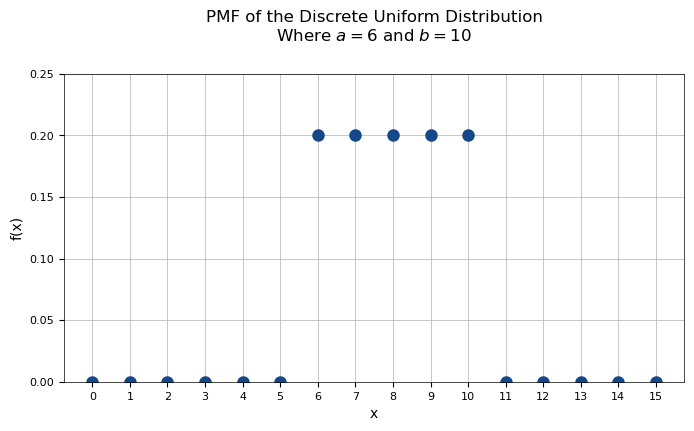

In [487]:
# Plot of the Probability Mass Function for the
# Discrete Uniform Distribution
# fig:W00_PMF1

# Plot the results
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")

# Format the axes
plot.xticks(uniform_x_values)

# Label the axes
plot.xlabel("x")
plot.ylabel("f(x)")

# Limit the axes
plot.ylim(0, 0.25)

# Label the plot
plot.title(
    "PMF of the Discrete Uniform Distribution\n"
    "Where $a = $" + str(a) + " and $b = $" + str(b),
    pad=24.0,
)

plot.plot(
    uniform_x_values,
    sp.stats.randint.pmf(uniform_x_values, low, high),
    color=signal_colours["blue"],
    linestyle="none",
    marker="o",
    markersize=8,
    label="randint pmf",
)

The CDF can now be calculated in the same way, using the same `uniform_x_values` for the $x$ axis. This requires calling the using the [`cdf` method](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html#scipy.stats.randint) of `randint`, as in `Line 30` of the code below. This should produce the CDF shown in [@fig:W00_CDF1].

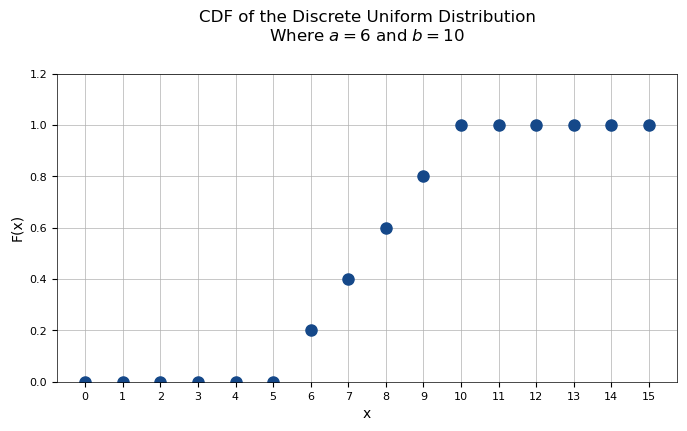

In [488]:
# Plot of the Cumulative Distribution Function for the
# Discrete Uniform Distribution
# fig:W00_CDF1

# Plot the results
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")

# Format the axes
plot.xticks(uniform_x_values)

# Label the axes
plot.xlabel("x")
plot.ylabel("F(x)")

# Limit the axes
plot.ylim(0, 1.2)

# Label the plot
plot.title(
    "CDF of the Discrete Uniform Distribution\n"
    "Where $a = $" + str(a) + " and $b = $" + str(b),
    pad=24.0,
)

plot.plot(
    uniform_x_values,
    sp.stats.randint.cdf(uniform_x_values, low, high),
    color=signal_colours["blue"],
    linestyle="none",
    marker="o",
    markersize=8,
    label="randint cdf",
)

#### Calculating the PMF and CDF by Hand

You should now also be able to calculate the PMF and CDF 'by hand', as we did for the continuous uniform distribution. To compare the two versions, we will also reuse the interval for the $x$ axis, `uniform_x_values`, calculated previously.

Starting with the PDF, we need to record the PMF for the first plot on the $y$ axis. We have already seen this: the only difference is the use of a variable to store the plot, rather than plotting the PMF directly

In [489]:
y1 = sp.stats.randint.pmf(uniform_x_values, low, high)

For the second $y$ axis, we need a variable in the same 'shape' (range) as `uniform_x_values`, so we will use the [NumPy `zeros_like`](https://numpy.org/doc/stable/reference/generated/numpy.zeros_like.html) method to create the array. We know from [@tbl:W00_DUniformPDF] the PMF is defined as

$$f[x]={\begin{cases}{\dfrac {1}{n}}&{\text{for }}x \in [[a \ldots b]],\\ 0&{\text{for }}x< a {\text{ or }}x > b\end{cases}}$$

We can assume the `zeros_like` method will set the $0$ values outside the discrete interval $[[a ... b]]$^[There is a slight complication here, shown in `Line 3`. Since NumPy has created a discrete range for `uniform_x_value`, by default `y2` will _also_ be discrete (`dtype=int`). This means $\frac{1}{n}$ will always be zero, since the calculation will be rounded to the nearest integer. We actually need `y2` to hold floating point values, so we have to force NumPy to do this using the `dtype` (data type) parameter.]. This means we only need to take into account the values between $a$ and $b$. From [@tbl:W00_DUniformPDF], the PMF calculation in this range should be 

$$ f(x) = \frac{1}{n}$$

Where $n = b - a +1$. This gives the calculation for the second $y$ axis, `y2` as

In [490]:
# Calculate a new PMF from the formula over the range of
# x-axis values specified in `uniform_x_values`
y2 = np.zeros_like(uniform_x_values, dtype=float)

n = b - a + 1

for i in uniform_x_values:

    if i >= a and i <= b:
        y2[i] = 1.0 / (n)

output = f"PMF Distribution:\n\
    {np.array2string(y2, formatter={'float': lambda x: f'{x:.1f}'})}"

print(
    textwrap.fill(
        output,
        60,
        subsequent_indent="                       ",
    )
)

PMF Distribution:     [0.0 0.0 0.0 0.0 0.0 0.0 0.2 0.2 0.2
                       0.2 0.2 0.0 0.0 0.0 0.0 0.0]


Now all that remains is to plot the two values of `y1` and `y2` together, as in [@fig:W00_HandPlot3]. Here the larger blue markers are the values calculated previously from the `pdf` method, and the smaller orange markers are the values just calculated.

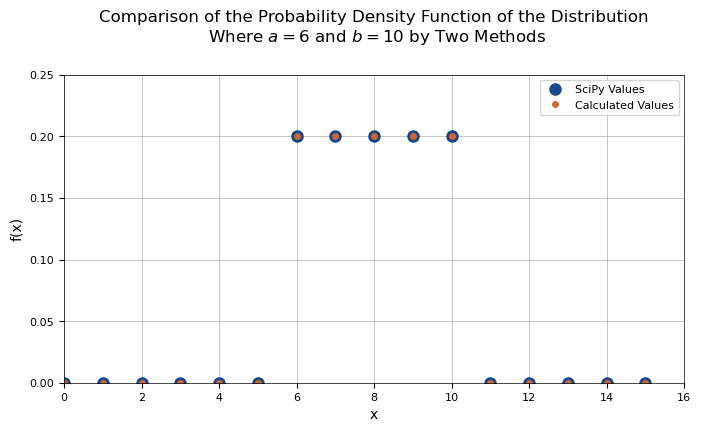

In [491]:
# Comparison of the PMF Output from the SciPy library and
# Direct Calculation for the Discrete Uniform Distribution
# fig:W00_HandPlot3

# Plot the results
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")

# Format the axes
# plot.xticks(x_axis_ticks)

# Label the axes
plot.xlabel("x")
plot.ylabel("f(x)")

# Limit the axes
plot.xlim(0, 16)
plot.ylim(0, 0.25)

# Label the plot
plot.title(
    "Comparison of the Probability Density Function of the "
    "Distribution\n Where $a = $"
    + str(a)
    + " and $b = $"
    + str(b)
    + " by Two Methods",
    pad=24.0,
)

# Plot the two y-axes on the same plot
plot.plot(
    uniform_x_values,
    y1,
    linestyle="none",
    marker="o",
    markersize=8,
    label="SciPy Values",
)
plot.plot(
    uniform_x_values,
    y2,
    linestyle="none",
    marker="o",
    markersize=4,
    label="Calculated Values",
)

# Add a legend
plot.legend(loc="best")

The final exercise is to plot the CDF of the discrete uniform distribution from [@tbl:W00_DUniformPDF] 

$$F[x]={\begin{cases}0 & {\text{for }}x < a,\\ {\dfrac{x-a+1}{n}}&{\text{for }}x \in [[a \ldots b]],\\ 1&{\text{for }}x > b\end{cases}}$$

We could reuse `n`, but for completeness we will recalculate this in `Line 5`. As usual `y2` is also initialised to an array of `0` values, being careful to account for the data type. The interval calculation is slightly more complex, as we need to ensure that $y=1$ when $b>n$. Inside the interval, the calculation is a straight copy of the definition above. Putting this together gives

In [492]:
# Calculate a new CDF from the formula over the range of
# x-axis values specified in `uniform_x_values`
y2 = np.zeros_like(uniform_x_values, dtype=float)

n = b - a + 1

for i in uniform_x_values:

    if i >= a and i <= b:
        y2[i] = (i - a + 1) / (n)
    elif i > b:
        y2[i] = 1.0

output = f"CDF Distribution:\n \
    {np.array2string(y2, formatter={'float': lambda x: f'{x:.1f}'})}"

print(
    textwrap.fill(
        output,
        60,
        subsequent_indent="                        ",
    )
)

CDF Distribution:      [0.0 0.0 0.0 0.0 0.0 0.0 0.2 0.4 0.6
                        0.8 1.0 1.0 1.0 1.0 1.0 1.0]


Using the library version of the CDF for `y1`, we can now plot the two distributions together

In [493]:
y1 = sp.stats.randint.cdf(uniform_x_values, low, high)

The final plot in [@fig:W00_HandPlot4] is also much the same as previously. Again the larger blue markers are the values calculated previously from the `cdf` method, and the smaller orange markers are the values just calculated.

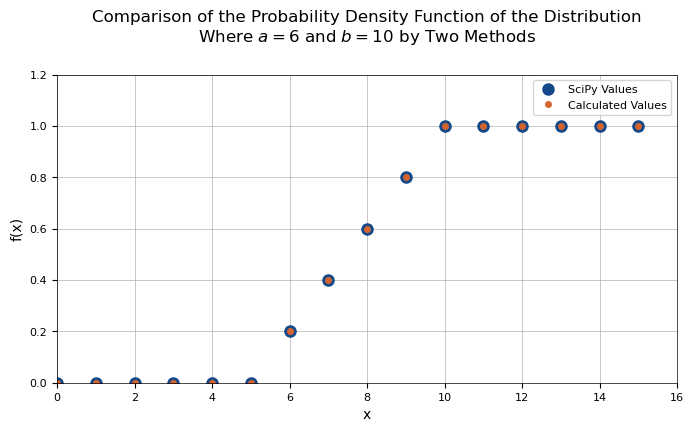

In [494]:
# Comparison of the CDF Output from the SciPy library and
# Direct Calculation for the Discrete Uniform Distribution
# fig:W00_HandPlot4

# Plot the results
plot.figure(figsize=(8, 4))

# Format the plot
plot.grid(True, which="both")

# Format the axes
# plot.xticks(x_axis_ticks)

# Label the axes
plot.xlabel("x")
plot.ylabel("f(x)")

# Limit the axes
plot.xlim(0, 16)
plot.ylim(0, 1.2)

# Label the plot
plot.title(
    "Comparison of the Probability Density Function of the "
    "Distribution\nWhere $a = $"
    + str(a)
    + " and $b = $"
    + str(b)
    + " by Two Methods",
    pad=24.0,
)

plot.figure.titlewight = "heavy"

# Plot the two y-axes on the same plot
plot.plot(
    uniform_x_values,
    y1,
    linestyle="none",
    marker="o",
    markersize=8,
    label="SciPy Values",
)
plot.plot(
    uniform_x_values,
    y2,
    linestyle="none",
    marker="o",
    markersize=4,
    label="Calculated Values",
)

# Add a legend
plot.legend(loc="best")

\clearpage

## Questions

Use Python to answer the following questions. Where appropriate give answers to 4 decimal places.

1. Create a continuous uniform distribution that chooses any value between 2 and 10. Calculate using the expressions the mean, variance, PDF and CDF of the distribution. Then use Python to confirm the calculated values.

*Answer*:


In [495]:
# code for question 1

2. Create a continuous uniform distribution that models a processing time where all values between 0.2 and 0.6s are equally likely. Calculate using the expressions the mean, variance, PDF and CDF of the distribution. Then use Python to confirm the calculated values.

*Answer*:


In [496]:
# code for question 2

3. Create a uniform distribution to model a dice. Calculate using the expressions the mean, variance, PDF and CDF of the distribution and then use Python to confirm the calculated values.

*Answer*:


In [497]:
# code for question 3

4. We need to model packet interarrival time that is can take discrete values in space $\{0.1, 0.14,...,0.46,0.5\}sec$. Create a distribution to model this and calculate the mean, variance, PDF and CDF of the distribution. Then use Python to confirm the calculated values.

*Answer*:


In [498]:
# code for question 4